# Parte 2 - Análisis de Pérdidas en Producción

## Objetivo

Identificar si las pérdidas de producción se concentran principalmente en determinadas máquinas, líneas o turnos, con el fin de priorizar acciones correctivas dentro del proceso productivo.

## Contexto

La planta de manufactura busca reducir pérdidas operativas, pero actualmente no cuenta con evidencia suficiente para determinar si estas pérdidas provienen principalmente de defectos de calidad, paradas no planificadas o una combinación de ambas.

## Preparación del Entorno Analítico
 
En esta sección se cargan las librerías necesarias para conectarse a la base de datos SQLite, manipular los datos y construir visualizaciones que faciliten la interpretación de los resultados.

- Conectarse a SQLite.
- Manipular datos mediante Pandas.
- Crear visualizaciones.
- Realizar análisis exploratorio.

In [9]:
# Manejo de base de datos
import sqlite3

# Manipulación de datos
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
plt.style.use("default")

# Mostrar todas las columnas
pd.set_option("display.max_columns", None)

# Conexión a SQLite
conn = sqlite3.connect("manufacturing.db")

print("Conexión exitosa")

Conexión exitosa


# Carga de Tablas

Se cargan las tablas utilizadas durante el análisis.

Estas tablas representan:

- Producción.
- Eventos de parada.
- Máquinas.
- Turnos.

In [10]:
# Lectura de órdenes de producción
orders = pd.read_sql(
    "SELECT * FROM production_orders",
    conn
)

# Lectura de eventos de parada
downtime = pd.read_sql(
    "SELECT * FROM downtime_events",
    conn
)

# Lectura de máquinas
machines = pd.read_sql(
    "SELECT * FROM machines",
    conn
)

# Lectura de turnos
shifts = pd.read_sql(
    "SELECT * FROM shifts",
    conn
)

print("Órdenes:", orders.shape)
print("Eventos:", downtime.shape)
print("Máquinas:", machines.shape)
print("Turnos:", shifts.shape)

Órdenes: (10000, 9)
Eventos: (10000, 7)
Máquinas: (50, 4)
Turnos: (3, 4)


## Preguntas Analíticas
 
Para transformar la necesidad planteada por el negocio en análisis concretos se definieron las siguientes preguntas:
 
1. ¿Qué máquinas presentan la mayor tasa de defectos?
2. ¿Qué líneas concentran más problemas de calidad?
3. ¿Qué turnos presentan peor desempeño?
4. ¿Qué máquinas presentan más paradas no planificadas?
5. ¿Cuáles son las principales causas de parada?
6. ¿Dónde se concentran realmente las pérdidas?

# Análisis de Calidad por Máquina

## Pregunta

¿Qué máquinas presentan la mayor tasa de defectos?

## Justificación

La cantidad absoluta de defectos no permite comparar máquinas de manera justa.

Por esta razón se calcula:

Defect Rate = Unidades Defectuosas / Unidades Producidas

La métrica permite identificar los equipos con peor desempeño relativo.

In [11]:
# Agrupación por máquina

machine_defects = (

    orders

    .groupby("machine_id")

    .agg(
        total_produced=("units_produced", "sum"),
        total_defective=("units_defective", "sum")
    )

    .reset_index()
)

# Cálculo de la tasa de defectos

machine_defects["defect_rate"] = (

    machine_defects["total_defective"]

    /

    machine_defects["total_produced"]

) * 100

# Orden descendente

machine_defects = machine_defects.sort_values(
    "defect_rate",
    ascending=False
)

machine_defects.head(10)

,machine_id,total_produced,total_defective,defect_rate
1,2,44721,1889,4.223966
7,8,50749,2064,4.067075
48,49,51835,2096,4.043600
12,13,53930,2169,4.021880
22,23,56334,2240,3.976284
41,42,57627,2284,3.963420
31,32,54483,2159,3.962704
28,29,58113,2289,3.938878
4,5,59335,2324,3.916744
40,41,48027,1877,3.908218


## Resultado

Las máquinas ubicadas en las primeras posiciones representan las principales fuentes de pérdida por calidad y deberían ser priorizadas para revisión técnica y mantenimiento.

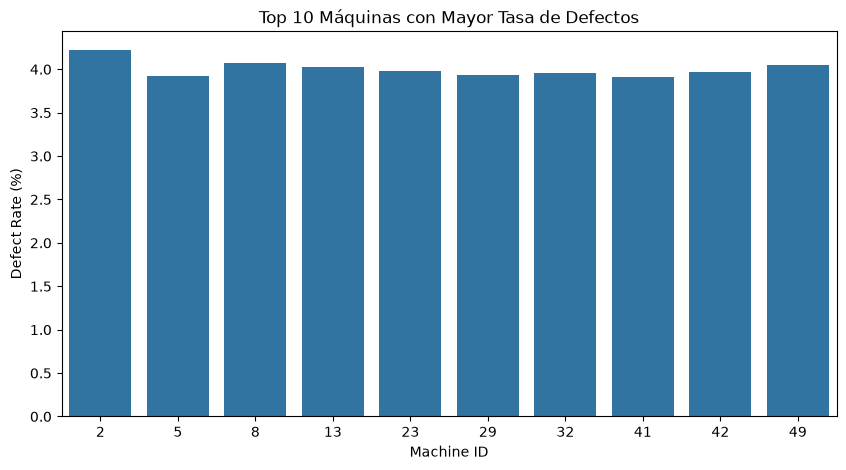

In [12]:
# Selección de las 10 máquinas más críticas

top_defects = machine_defects.head(10)

# Visualización

plt.figure(figsize=(10,5))

sns.barplot(
    data=top_defects,
    x="machine_id",
    y="defect_rate"
)

plt.title(
    "Top 10 Máquinas con Mayor Tasa de Defectos"
)

plt.xlabel("Machine ID")

plt.ylabel("Defect Rate (%)")

plt.show()

# Análisis por Línea de Producción

## Pregunta

¿Las pérdidas de calidad se concentran en determinadas líneas?

## Justificación

Si varias máquinas pertenecientes a una misma línea presentan problemas, el origen podría encontrarse en el proceso productivo y no únicamente en equipos individuales.

In [13]:
# ====================================
# ANÁLISIS POR LÍNEA
# ====================================

line_analysis = (

    orders

    .groupby("line_id")

    .agg(
        produced=(
            "units_produced",
            "sum"
        ),
        defective=(
            "units_defective",
            "sum"
        )
    )

    .reset_index()
)

line_analysis["defect_rate"] = (

    line_analysis["defective"]

    /

    line_analysis["produced"]

) * 100

line_analysis.sort_values(
    "defect_rate",
    ascending=False
)

,line_id,produced,defective,defect_rate
2,3,427392,16397,3.836525
0,1,331526,12618,3.806036
1,2,348739,13273,3.805998
4,5,215631,8197,3.801401
6,7,163170,6135,3.759882
3,4,398859,14924,3.741673
8,9,262743,9746,3.709328
9,10,162926,6034,3.703522
5,6,162287,5977,3.682981
7,8,276959,10198,3.682133


# Grafico analisis por linea

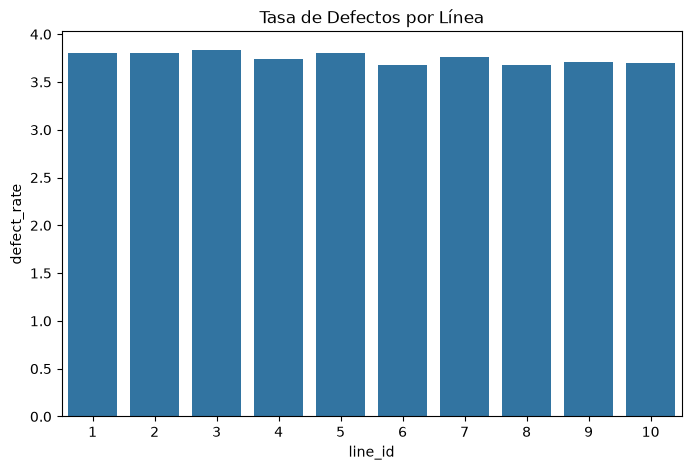

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=line_analysis,
    x="line_id",
    y="defect_rate"
)

plt.title(
    "Tasa de Defectos por Línea"
)

plt.show()


## Interpretación

Las líneas con mayores tasas de defectos representan oportunidades de mejora con impacto sobre múltiples máquinas al mismo tiempo.

# Análisis por Turno

## Pregunta de Negocio

¿Existen diferencias relevantes entre turnos?

## Justificación

Diferencias entre turnos pueden indicar problemas asociados a:

- Procedimientos.
- Supervisión.
- Capacitación.
- Distribución de carga operativa.


In [15]:
shift_analysis = (

    orders

    .groupby("shift_id")

    .agg(
        produced=(
            "units_produced",
            "sum"
        ),
        defective=(
            "units_defective",
            "sum"
        )
    )

    .reset_index()
)

shift_analysis["defect_rate"] = (

    shift_analysis["defective"]

    /

    shift_analysis["produced"]

) * 100

shift_analysis


,shift_id,produced,defective,defect_rate
0,1,926766,35328,3.811965
1,2,912846,34179,3.744224
2,3,910620,33992,3.732841


# Grafico analsis por turno

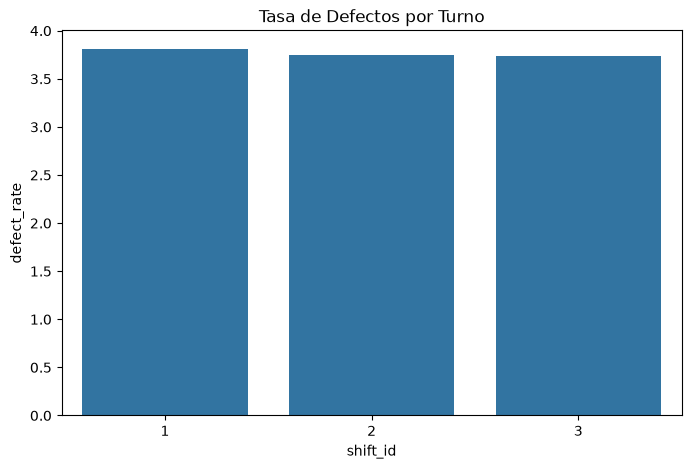

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=shift_analysis,
    x="shift_id",
    y="defect_rate"
)

plt.title(
    "Tasa de Defectos por Turno"
)

plt.show()


## Interpretación

Los resultados permiten identificar si existe algún turno con desempeño inferior respecto al resto de la operación.

# Análisis de Disponibilidad Operativa

## Pregunta de Negocio

¿Qué máquinas generan mayor pérdida por tiempo detenido?

## Justificación

Las paradas no planificadas representan pérdida directa de capacidad productiva y afectan el cumplimiento de objetivos operacionales.

In [17]:
# ====================================
# PREPARACIÓN DE FECHAS
# ====================================

downtime["start_time"] = pd.to_datetime(
    downtime["start_time"]
)

downtime["end_time"] = pd.to_datetime(
    downtime["end_time"]
)

# ====================================
# DURACIÓN DE LA PARADA
# ====================================

downtime["downtime_minutes"] = (

    downtime["end_time"]

    -

    downtime["start_time"]

).dt.total_seconds() / 60

## Eventos no planificados 


In [18]:
# ====================================
# EVENTOS NO PLANIFICADOS
# ====================================

unplanned = downtime[
    downtime["type"] == "unplanned"
]

machine_downtime = (

    unplanned

    .groupby("machine_id")

    .agg(
        downtime_minutes=(
            "downtime_minutes",
            "sum"
        )
    )

    .reset_index()

    .sort_values(
        "downtime_minutes",
        ascending=False
    )
)

machine_downtime.head(10)

,machine_id,downtime_minutes
34,35,11397.0
31,32,11168.0
25,26,11110.0
35,36,10982.0
16,17,10873.0
8,9,10749.0
27,28,10452.0
46,47,10407.0
11,12,10273.0
12,13,10155.0


# Grafico minutos perdidos por maquina



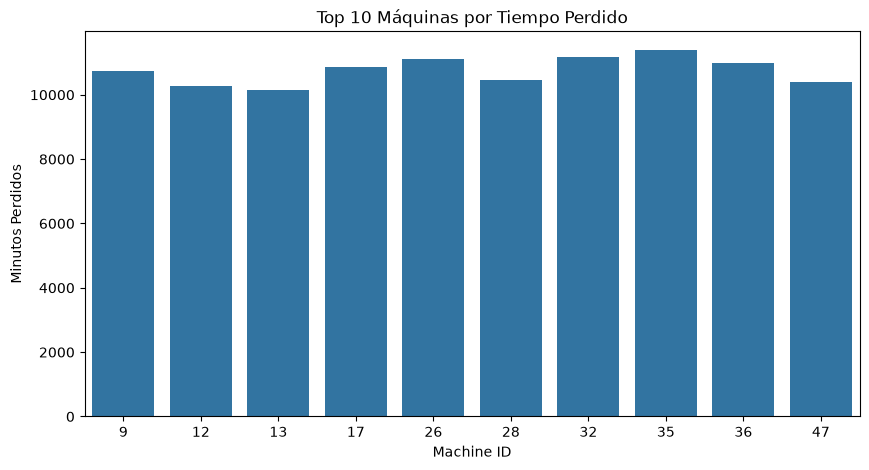

In [19]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=machine_downtime.head(10),
    x="machine_id",
    y="downtime_minutes"
)

plt.title(
    "Top 10 Máquinas por Tiempo Perdido"
)

plt.xlabel("Machine ID")
plt.ylabel("Minutos Perdidos")

plt.show()

## Interpretación

Las máquinas con mayor tiempo acumulado de parada representan los principales candidatos para mantenimiento preventivo y análisis de causa raíz.

# Análisis de Causas de Parada

## Pregunta de Negocio

¿Cuáles son las causas más frecuentes de indisponibilidad?

## Justificación

Identificar las causas predominantes permite priorizar recursos y esfuerzos de mantenimiento sobre los problemas que generan mayor impacto.

In [20]:
causes = (

    unplanned

    .groupby("reason_code")

    .size()

    .reset_index(
        name="events"
    )

    .sort_values(
        "events",
        ascending=False
    )
)

causes

,reason_code,events
4,MEC-02,1025
0,CAL-01,1020
1,ELEC-01,1001
2,MAT-01,989
3,MEC-01,978


# Grafico frecuencia de eventos 

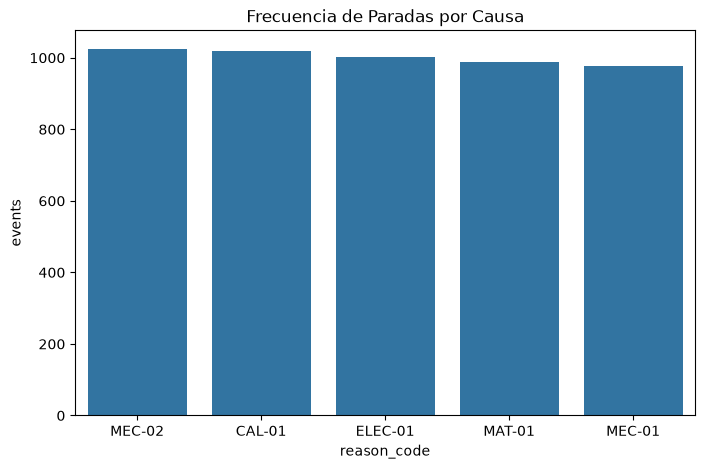

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=causes,
    x="reason_code",
    y="events"
)

plt.title(
    "Frecuencia de Paradas por Causa"
)

plt.show()

# 9. Hallazgos Principales

A partir del análisis realizado se identificaron:

- Las máquinas con mayor tasa de defectos.
- Las líneas con mayores pérdidas de calidad.
- Los turnos con peor desempeño.
- Las máquinas con mayor tiempo de parada.
- Las causas más frecuentes de indisponibilidad.

Estos resultados proporcionan evidencia objetiva para priorizar acciones correctivas y mejorar la eficiencia operacional.

# 10. Recomendaciones

## Corto Plazo

- Revisar las máquinas con peores indicadores de calidad.
- Analizar las causas principales de parada.
- Implementar seguimiento periódico de indicadores.

## Mediano Plazo

- Fortalecer el mantenimiento preventivo.
- Establecer metas de reducción de defectos.
- Realizar seguimiento por turno y línea.

## Largo Plazo

- Construir dashboards operativos.
- Implementar analítica predictiva.
- Desarrollar modelos de predicción de fallas y defectos.

# Visión para Otros Roles

## Analista de Negocio

Construcción de KPIs y tableros de seguimiento.

## Científico de Datos

Predicción de defectos y fallas futuras.

## Operaciones

Priorización objetiva de recursos críticos basada en datos.